# Stored vs. New CBSS Calibration for Adaptive EMG Decomposition

Compares two calibration strategies on the simulated forearm HD-EMG dataset in `data/example`, which (unlike a real recording) includes **true ground-truth spike trains** from the NeuroMotion simulation:

| Path | Calibration source | Unit selection |
|------|--------------------|-----------------|
| **A — Stored** | Pre-computed decomposition (`decomp_sim.mat`) from the isometric calibration segment — a previously decomposed calibration | All units (no filtering) |
| **B — New** | `calibrate_from_indices()` re-runs the integrated CBSS pipeline on the same calibration window | `select_units_supervised()` keeps units with RoA ≥ 0.9 vs. the **true simulated spikes** |

Both calibrations are fed into `AdaptDecomp` for the full dynamic (staircase wrist-angle) recording. Because the ground truth is known here, the adaptation results from each calibration path can be scored directly against it, rather than only against each other.

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from pathlib import Path
from matplotlib.patches import Rectangle

from adapt_decomp.loaders import load_example
from adapt_decomp.adaptation import AdaptDecomp
from adapt_decomp.config import Config
from adapt_decomp import CBSSConfig, calibrate_from_indices, select_units_supervised
from adapt_decomp.utils import rate_of_agreement, rate_of_agreement_paired

%load_ext autoreload
%autoreload 2

sns.set_theme(style='whitegrid', font_scale=1.1)
COLORS = dict(no_adapt='tab:orange', adapt='tab:blue')

plt.rcParams.update({'figure.dpi': 100})

## 1. Load data

In [2]:
# ---- paths ----
path_emg = Path('..', 'data', 'example', 'data_sim.hdf5')
path_decomp = Path('..', 'data', 'example', 'decomp_sim.mat')

data = load_example(path_emg, path_decomp, False)

fs = data['fs']
ext_fact = data['ext_fact']
n_samples, n_chs = data['emg'].shape
calib_slice = slice(0, data['emg_calib'].shape[0])  # isometric calibration segment

print(f'Recording:   {n_samples} samples  ({n_samples/fs:.1f} s)  |  {n_chs} ch  |  fs={fs} Hz')
print(f'ext_fact:    {ext_fact}')
print(f'Calib phase: samples {calib_slice.start}-{calib_slice.stop}  ({(calib_slice.stop-calib_slice.start)/fs:.1f} s)')
print(f'Stored calibration units: {data["sep_vectors"].shape[0]}')
print(f'Ground-truth units (full simulated pool): {data["spikes_gt"].shape[1]}')

Recording:   389120 samples  (190.0 s)  |  320 ch  |  fs=2048 Hz
ext_fact:    3
Calib phase: samples 0-61440  (30.0 s)
Stored calibration units: 18
Ground-truth units (full simulated pool): 100


Take a look at the data — wrist angle and force profile, with the calibration phase shaded.

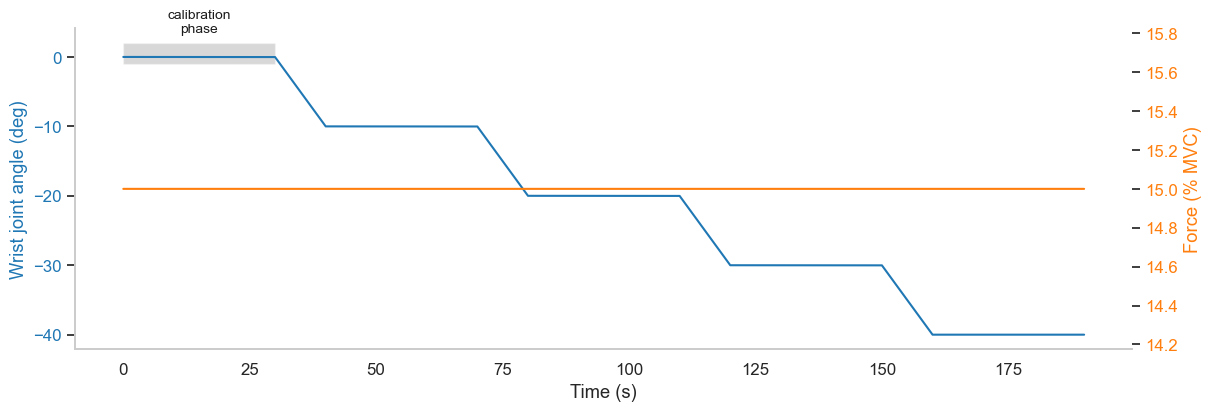

In [3]:
fig, axs = plt.subplots(1, 1, figsize=(12, 4), layout='constrained')

calib_dur = calib_slice.stop / fs
axs.add_patch(Rectangle((0, -1), calib_dur, 3, facecolor='grey', edgecolor=None, alpha=0.3))
axs.text(calib_dur / 2, 5, 'calibration\nphase', dict(ha='center', va='center', fontsize=10, color='k'))
axs.plot(data['timestamps'], data['angle_profile'], color='tab:blue')
axs.tick_params(axis='y', labelcolor='tab:blue')
axs.set_ylabel('Wrist joint angle (deg)', color='tab:blue')
axs.set_xlabel('Time (s)')
axs.grid(False)
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)

axs1 = axs.twinx()
axs1.plot(data['timestamps'], data['force_profile'], color='tab:orange')
axs1.tick_params(axis='y', labelcolor='tab:orange')
axs1.set_ylabel('Force (% MVC)', color='tab:orange')
axs1.spines['top'].set_visible(False)
axs1.spines['right'].set_visible(False)
axs1.grid(False)

plt.show()

## 2. Path A — Stored calibration

Build `AdaptDecomp` directly from the decomposition shipped in `decomp_sim.mat` — a calibration computed previously, offline.

In [4]:
def make_adapt_config(ext_fact: int, *, adapt: bool, log_loss: bool = True) -> Config:
    cfg = Config()
    cfg.ext_fact       = ext_fact
    cfg.log_loss       = log_loss
    cfg.device         = 'cpu'
    cfg.contrast_scope = 'spike_based'
    cfg.wh_mode        = 'kl_to_cal'
    cfg.batch_ms       = 100
    if not adapt:
        cfg.adapt_wh = False
        cfg.adapt_sv = False
        cfg.adapt_sd = False
    return cfg


def run_stored(adapt: bool):
    cfg = make_adapt_config(ext_fact, adapt=adapt)
    dec = AdaptDecomp(
        emg             = data['emg'].clone(),
        whitening       = data['whitening'].clone(),
        sep_vectors     = data['sep_vectors'].clone(),
        base_centroids  = data['base_centroids'].clone(),
        spike_centroids = data['spike_centroids'].clone(),
        emg_calib       = data['emg_calib'].clone(),
        ipts_calib      = data['ipts_calib'].clone(),
        spikes_calib    = data['spikes_calib'].clone(),
        preprocess      = data['preprocess'],
        config          = cfg,
    )
    return dec.run()

out_a_no  = run_stored(adapt=False)
print(f'[A / no-adapt]  done  |  units: {out_a_no["ipts"].shape[1]}')
out_a     = run_stored(adapt=True)
print(f'[A / adapt]     done  |  units: {out_a["ipts"].shape[1]}')

[A / no-adapt]  done  |  units: 18
[A / adapt]     done  |  units: 18


### 2.1 Match stored units to ground truth

`AdaptDecomp` is built directly from the stored calibration, so — unlike Path B — there is no automatic ground-truth match. We find one here using the calibration-phase spike trains, mirroring how `select_units_supervised()` matches Path B internally, but without filtering: every stored unit is kept regardless of match quality.

In [5]:
gt_spikes_calib = data['spikes_gt'][calib_slice].numpy().astype(np.int32)  # [T_calib, n_gt]

roa_a_calib, pair_a, lag_a = rate_of_agreement(
    gt_spikes_calib, out_a_no['spikes'].numpy()[calib_slice], fs=fs
)
gt_matched_a = np.array(pair_a)[:, 0]  # ground-truth unit index per stored unit

print(f'Matched {len(gt_matched_a)} / {out_a_no["ipts"].shape[1]} stored units to ground truth')
print(f'RoA at calibration: {roa_a_calib.mean()*100:.2f} ± {roa_a_calib.std()*100:.2f} (med {np.median(roa_a_calib)*100:.2f}) %')

Matched 18 / 18 stored units to ground truth
RoA at calibration: 99.40 ± 0.49 (med 99.35) %


## 3. Path B — New CBSS calibration + supervised unit selection

`calibrate_from_indices()` re-runs the full CBSS pipeline on the calibration window.
`select_units_supervised()` now matches against the **true simulated ground-truth spikes** instead of a stored reference decomposition, so the reported RoA is genuine decomposition accuracy rather than agreement with another algorithm run.

In [6]:
import pickle

RUN_CBSS = False  # set True to re-run the ~50-min decomposition; False loads the cached result

new_result_path = Path('..', 'data', 'example', 'cbss_new_calibration.pkl')

if RUN_CBSS:
    cbss_config = CBSSConfig(
        fs             = float(fs),
        ext_fact       = ext_fact,
        preprocess_emg = False,    # simulated EMG, no bandpass needed
        save_emg       = True,     # required by from_calibration()
        sil_th         = 0.9,
        search_iter    = 500,
        ica_iter       = 500,
        spike_min_dist_ms = 10.0,
        spike_det_exp  = 2.0,
        contrast_fun   = 'square',
        contrast_exp   = 3.0,
        compute_properties = True,
        random_seed    = 0,
        ch_map         = data['ch_map'].numpy(),
        device         = 'cpu',
    )
    print('Running CBSS on calibration window …')
    new_result = calibrate_from_indices(
        emg           = data['emg'].numpy(),
        timestamps    = data['timestamps'].numpy(),
        calib_indices = calib_slice,
        cbss_config   = cbss_config,
    )
    with open(new_result_path, 'wb') as f:
        pickle.dump(new_result, f)
    print(f'Saved to {new_result_path}')
else:
    with open(new_result_path, 'rb') as f:
        new_result = pickle.load(f)
    print(f'Loaded from {new_result_path}')

n_new = new_result.sources.shape[1]
print(f'CBSS result: {n_new} units')
print(f'  SIL  {new_result.sil.mean():.3f} ± {new_result.sil.std():.3f}')
print(f'  CoV  {new_result.cov.mean():.3f} ± {new_result.cov.std():.3f}')
if new_result.pnr is not None:
    print(f'  PNR  {new_result.pnr.mean():.1f} ± {new_result.pnr.std():.1f}')

Loaded from ..\data\example\cbss_new_calibration.pkl
CBSS result: 30 units
  SIL  0.953 ± 0.026
  CoV  0.289 ± 0.182
  PNR  23.2 ± 6.0


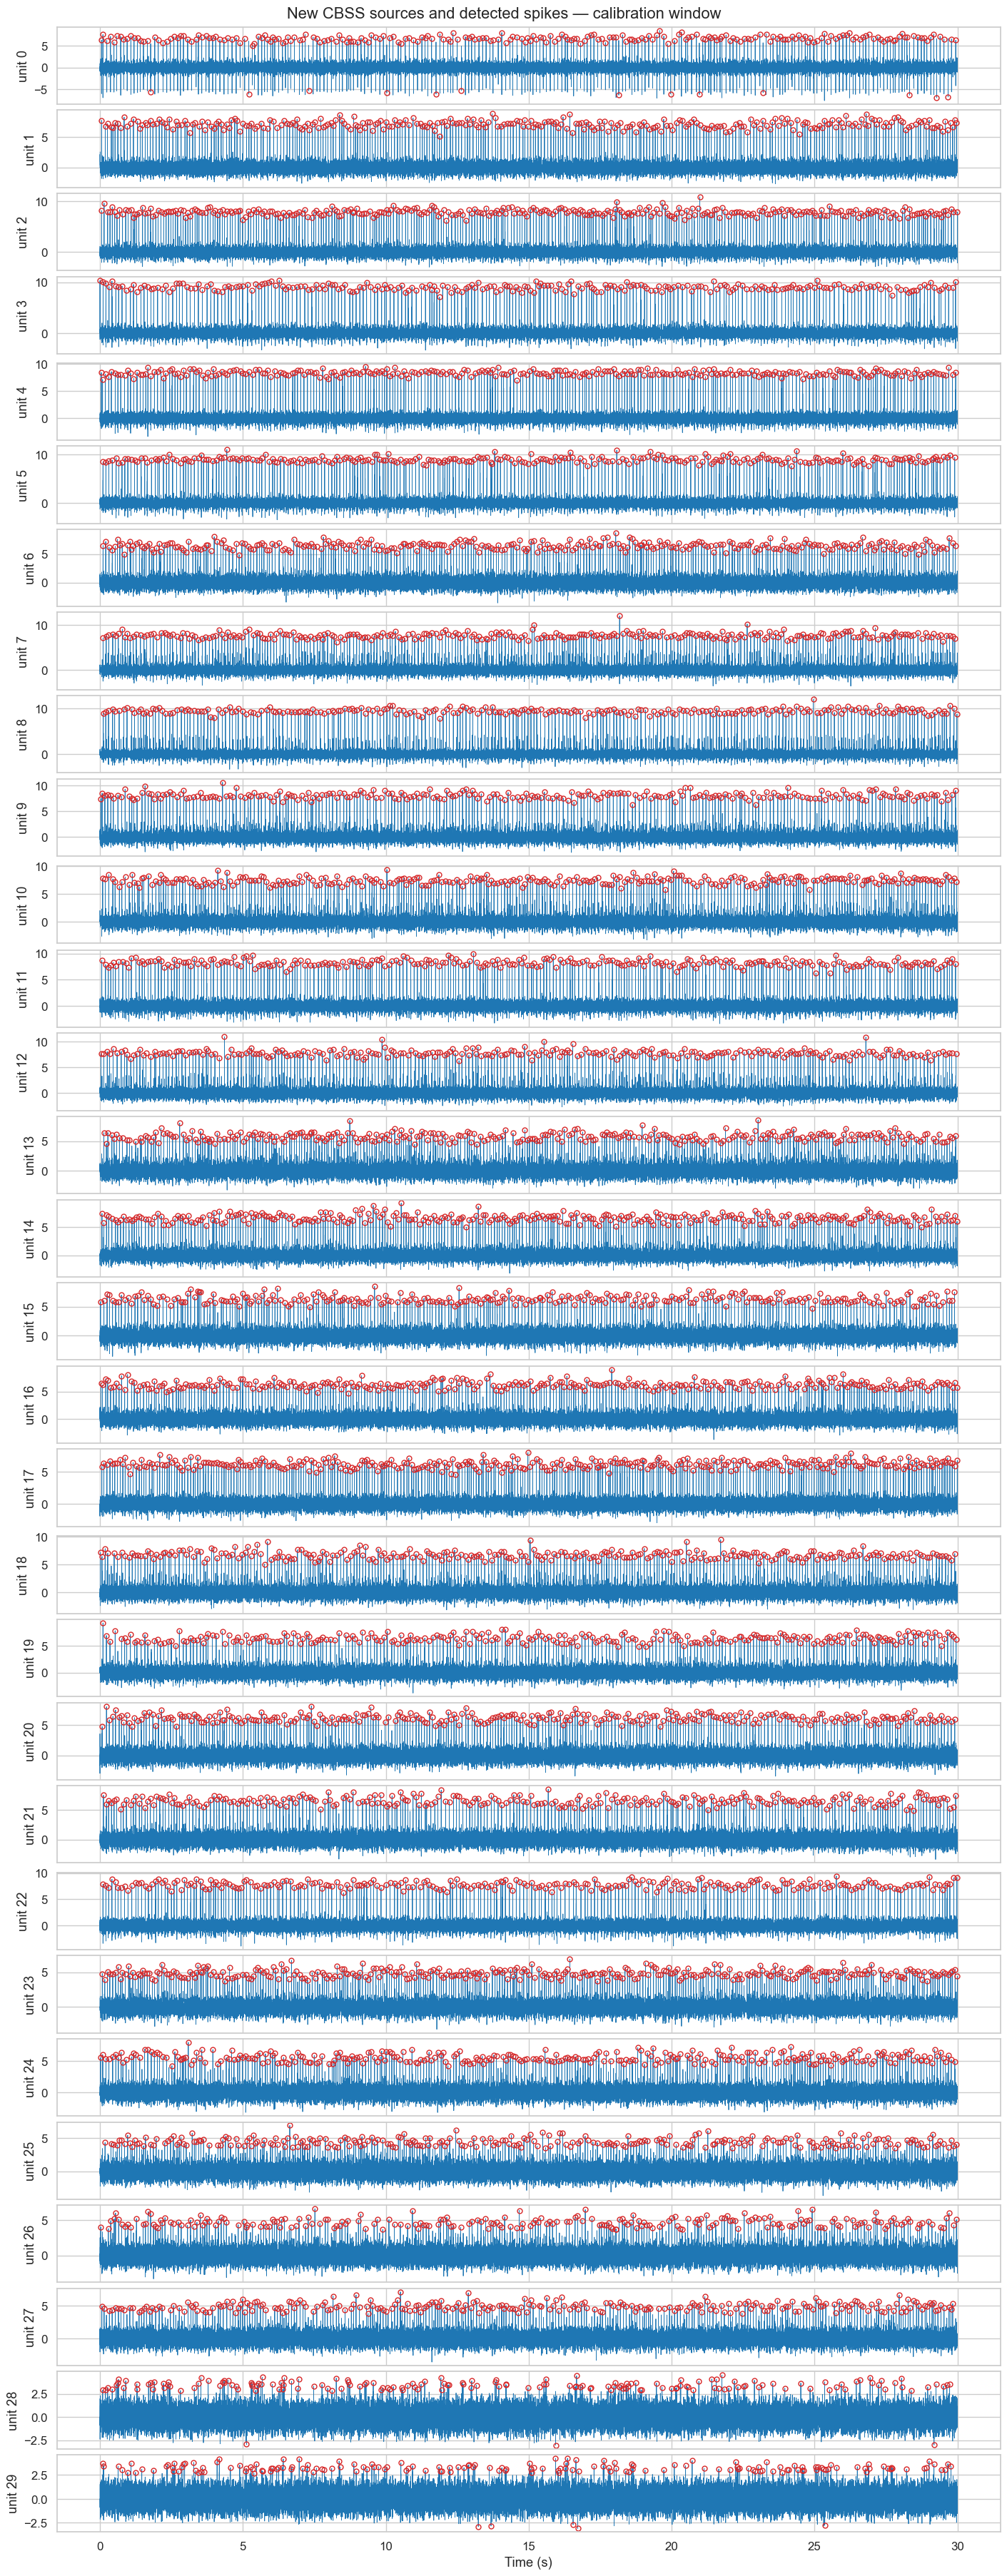

In [7]:
ts_calib = new_result.timestamps

fig, axes = plt.subplots(n_new, 1, figsize=(14, n_new * 1.2), layout='constrained', sharex=True)
if n_new == 1:
    axes = [axes]

for i in range(n_new):
    ax = axes[i]
    ax.plot(ts_calib, new_result.sources[:, i], color='tab:blue', lw=0.6)
    spike_idx = new_result.spikes_dict.get(i, np.array([], dtype=int))
    ax.plot(ts_calib[spike_idx], new_result.sources[spike_idx, i], 'o',
            color='tab:red', markerfacecolor='none', markersize=5)
    ax.set(ylabel=f'unit {i}')

axes[-1].set(xlabel='Time (s)')
plt.suptitle('New CBSS sources and detected spikes — calibration window')
plt.show()

In [8]:
roa_new_calib, pair_new, lag_new = rate_of_agreement(
    gt_spikes_calib, new_result.spikes, fs=fs
)

print(f'Matched {len(pair_new)} / {n_new} new units to ground truth (global greedy assignment)')
print(f'RoA at calibration: {roa_new_calib.mean()*100:.2f} ± {roa_new_calib.std()*100:.2f} (med {np.median(roa_new_calib)*100:.2f}) %')
for (gt_idx, new_idx), roa_val in zip(pair_new, roa_new_calib):
    print(f'  new unit {new_idx:>2}  ->  GT {gt_idx:>3}   RoA = {roa_val:.3f}')

Matched 30 / 30 new units to ground truth (global greedy assignment)
RoA at calibration: 90.57 ± 23.84 (med 99.44) %
  new unit  0  ->  GT  55   RoA = 1.000
  new unit  1  ->  GT  39   RoA = 1.000
  new unit  2  ->  GT  26   RoA = 0.997
  new unit  3  ->  GT  54   RoA = 1.000
  new unit  4  ->  GT  41   RoA = 1.000
  new unit  5  ->  GT  47   RoA = 1.000
  new unit  6  ->  GT  35   RoA = 0.997
  new unit  7  ->  GT  45   RoA = 0.996
  new unit  8  ->  GT  53   RoA = 0.996
  new unit  9  ->  GT  52   RoA = 1.000
  new unit 10  ->  GT  42   RoA = 1.000
  new unit 11  ->  GT  46   RoA = 0.996
  new unit 12  ->  GT  50   RoA = 1.000
  new unit 13  ->  GT  32   RoA = 0.965
  new unit 14  ->  GT  33   RoA = 1.000
  new unit 15  ->  GT  43   RoA = 0.986
  new unit 16  ->  GT  36   RoA = 0.990
  new unit 17  ->  GT  12   RoA = 0.997
  new unit 18  ->  GT  44   RoA = 0.993
  new unit 19  ->  GT  49   RoA = 0.981
  new unit 20  ->  GT  37   RoA = 0.977
  new unit 21  ->  GT  48   RoA = 0.989
  n

In [9]:
# Note to myself: The roa in comparison is not working - need to use my function implementations and translate them to tensors if possible/beneficial
(roa_new_calib >= 0.9).sum()

25

In [10]:
ROA_TH = 0.9

# True ground truth restricted to the calibration window — replaces the
# "stored decomposition as pseudo-GT" used when no real ground truth exists.
selected = select_units_supervised(
    new_result,
    gt_spikes_calib,
    roa_th = ROA_TH,
    tol_ms = 0.5,
    fs     = float(fs),
)

n_sel = selected.sources.shape[1]
print(f'Units after supervised selection (RoA ≥ {ROA_TH}):  {n_sel} / {n_new}')
print(f'Matched ground-truth unit indices:  {selected.gt_matched_indices}')

Units after supervised selection (RoA ≥ 0.9):  25 / 30
Matched ground-truth unit indices:  [55 39 26 54 41 47 35 45 53 52 42 46 50 32 33 43 36 12 44 49 37 48 51  5
 28]


In [12]:
def run_new(adapt: bool):
    cfg = make_adapt_config(ext_fact, adapt=adapt)
    dec = AdaptDecomp.from_calibration(
        emg         = data['emg'].numpy(),  # full recording
        calibration = selected,
        config      = cfg,
    )
    return dec.run()

out_b_no = run_new(adapt=False)
print(f'[B / no-adapt]  done  |  units: {out_b_no["ipts"].shape[1]}')
print(f'  gt_matched_indices: {out_b_no["gt_matched_indices"]}')

out_b = run_new(adapt=True)
print(f'[B / adapt]     done  |  units: {out_b["ipts"].shape[1]}')

[B / no-adapt]  done  |  units: 25
  gt_matched_indices: [55 39 26 54 41 47 35 45 53 52 42 46 50 32 33 43 36 12 44 49 37 48 51  5
 28]
[B / adapt]     done  |  units: 25


## 4. Comparison

### 4.1 Loss curves

C:\Users\Irene\AppData\Local\Temp\ipykernel_80024\2161238078.py:12: RuntimeWarning: Mean of empty slice
  sv_no = np.nanmean(out_no['sv_loss'].numpy(), axis=1)


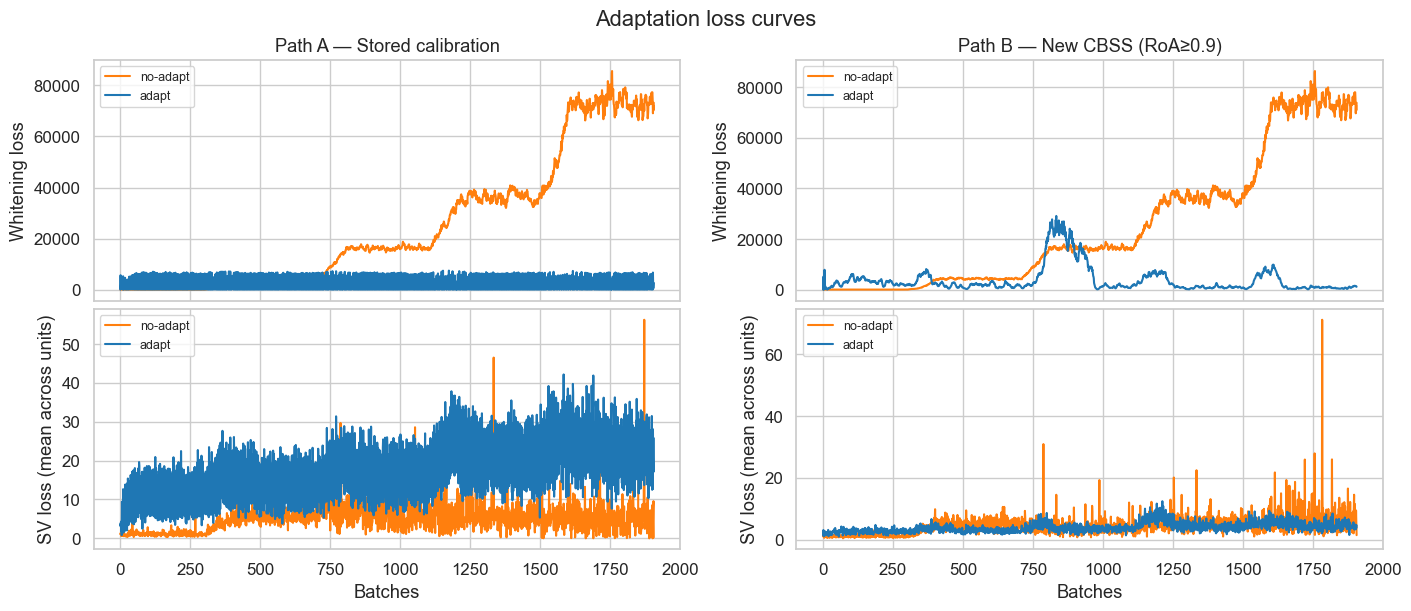

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 6), layout='constrained', sharex='col')

for col, (out_no, out_ad, title) in enumerate([
    (out_a_no, out_a, 'Path A — Stored calibration'),
    (out_b_no, out_b, f'Path B — New CBSS (RoA≥{ROA_TH})'),
]):
    axes[0, col].plot(out_no['wh_loss'].numpy()[:-1], label='no-adapt', color=COLORS['no_adapt'])
    axes[0, col].plot(out_ad['wh_loss'].numpy()[:-1], label='adapt',    color=COLORS['adapt'])
    axes[0, col].set(ylabel='Whitening loss', title=title)
    axes[0, col].legend(fontsize=9)

    sv_no = np.nanmean(out_no['sv_loss'].numpy(), axis=1)
    sv_ad = np.nanmean(out_ad['sv_loss'].numpy(), axis=1)
    axes[1, col].plot(sv_no[:-1], label='no-adapt', color=COLORS['no_adapt'])
    axes[1, col].plot(sv_ad[:-1], label='adapt',    color=COLORS['adapt'])
    axes[1, col].set(xlabel='Batches', ylabel='SV loss (mean across units)')
    axes[1, col].legend(fontsize=9)

plt.suptitle('Adaptation loss curves')
plt.show()

### 4.2 SV loss per unit

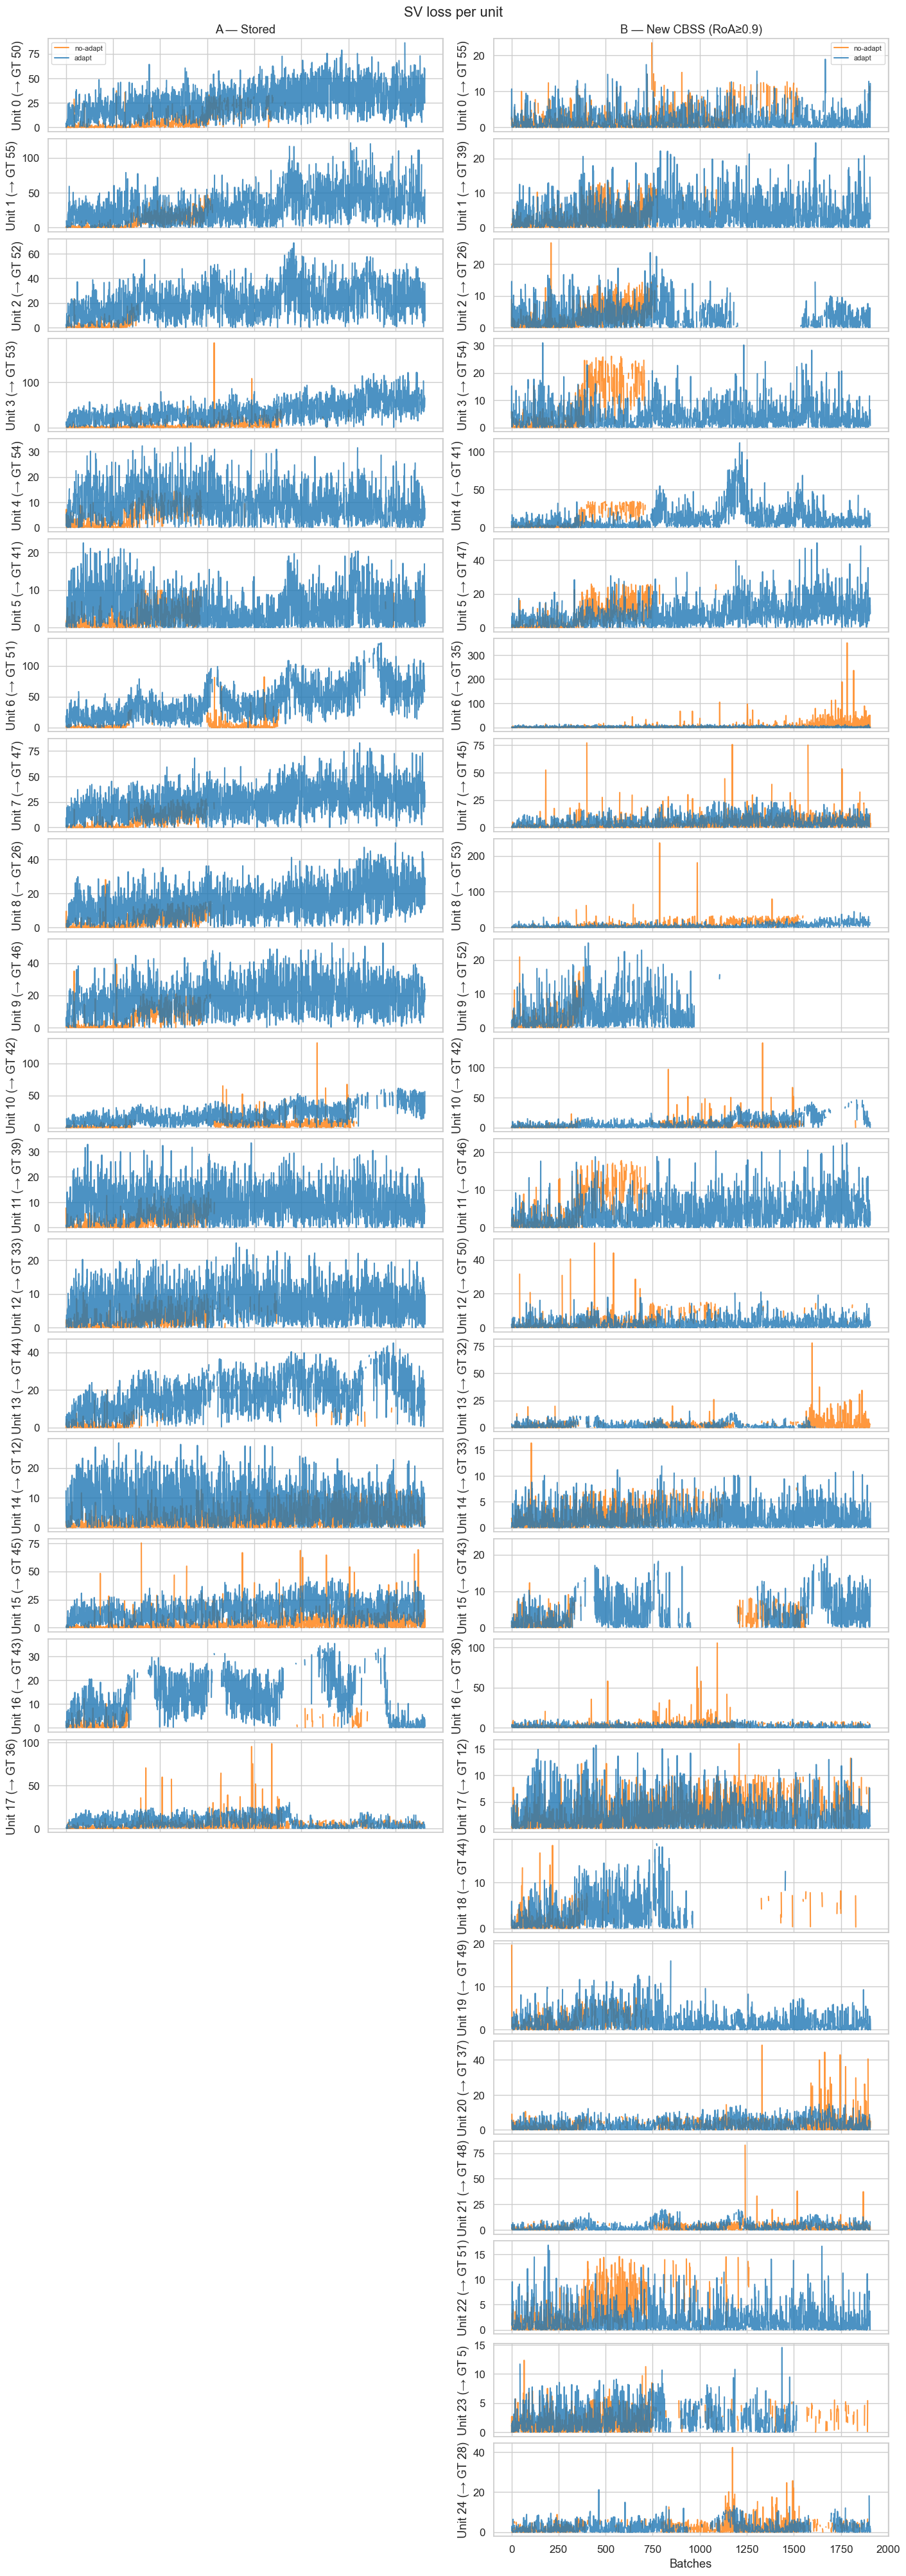

In [14]:
n_a = out_a['ipts'].shape[1]
n_b = out_b['ipts'].shape[1]
n_rows = max(n_a, n_b)

fig, axes = plt.subplots(n_rows, 2, figsize=(14, n_rows * 1.6), layout='constrained', sharex=True)
if n_rows == 1:
    axes = axes[np.newaxis, :]

for col, (out_no, out_ad, n_units, title) in enumerate([
    (out_a_no, out_a, n_a, 'A — Stored'),
    (out_b_no, out_b, n_b, f'B — New CBSS (RoA≥{ROA_TH})'),
]):
    for i in range(n_rows):
        ax = axes[i, col]
        if i >= n_units:
            ax.set_visible(False)
            continue
        ax.plot(out_no['sv_loss'][:, i].numpy(), label='no-adapt', color=COLORS['no_adapt'], alpha=0.8)
        ax.plot(out_ad['sv_loss'][:, i].numpy(), label='adapt',    color=COLORS['adapt'],    alpha=0.8)
        gt_lbl = f' (→ GT {gt_matched_a[i]})' if col == 0 else f' (→ GT {selected.gt_matched_indices[i]})'
        ax.set(ylabel=f'Unit {i}{gt_lbl}')
        if i == 0:
            ax.set_title(title)
            ax.legend(fontsize=8)

axes[-1, 0].set(xlabel='Batches')
axes[-1, 1].set(xlabel='Batches')
plt.suptitle('SV loss per unit')
plt.show()

### 4.3 Spike trains vs. ground truth

Plot IPT², detected spikes, and the true simulated spikes for the window of maximum wrist-angle deviation (where decomposition is hardest). This is only possible here because the dataset carries ground truth — with a real recording (the original version of this notebook) there is nothing to overlay.

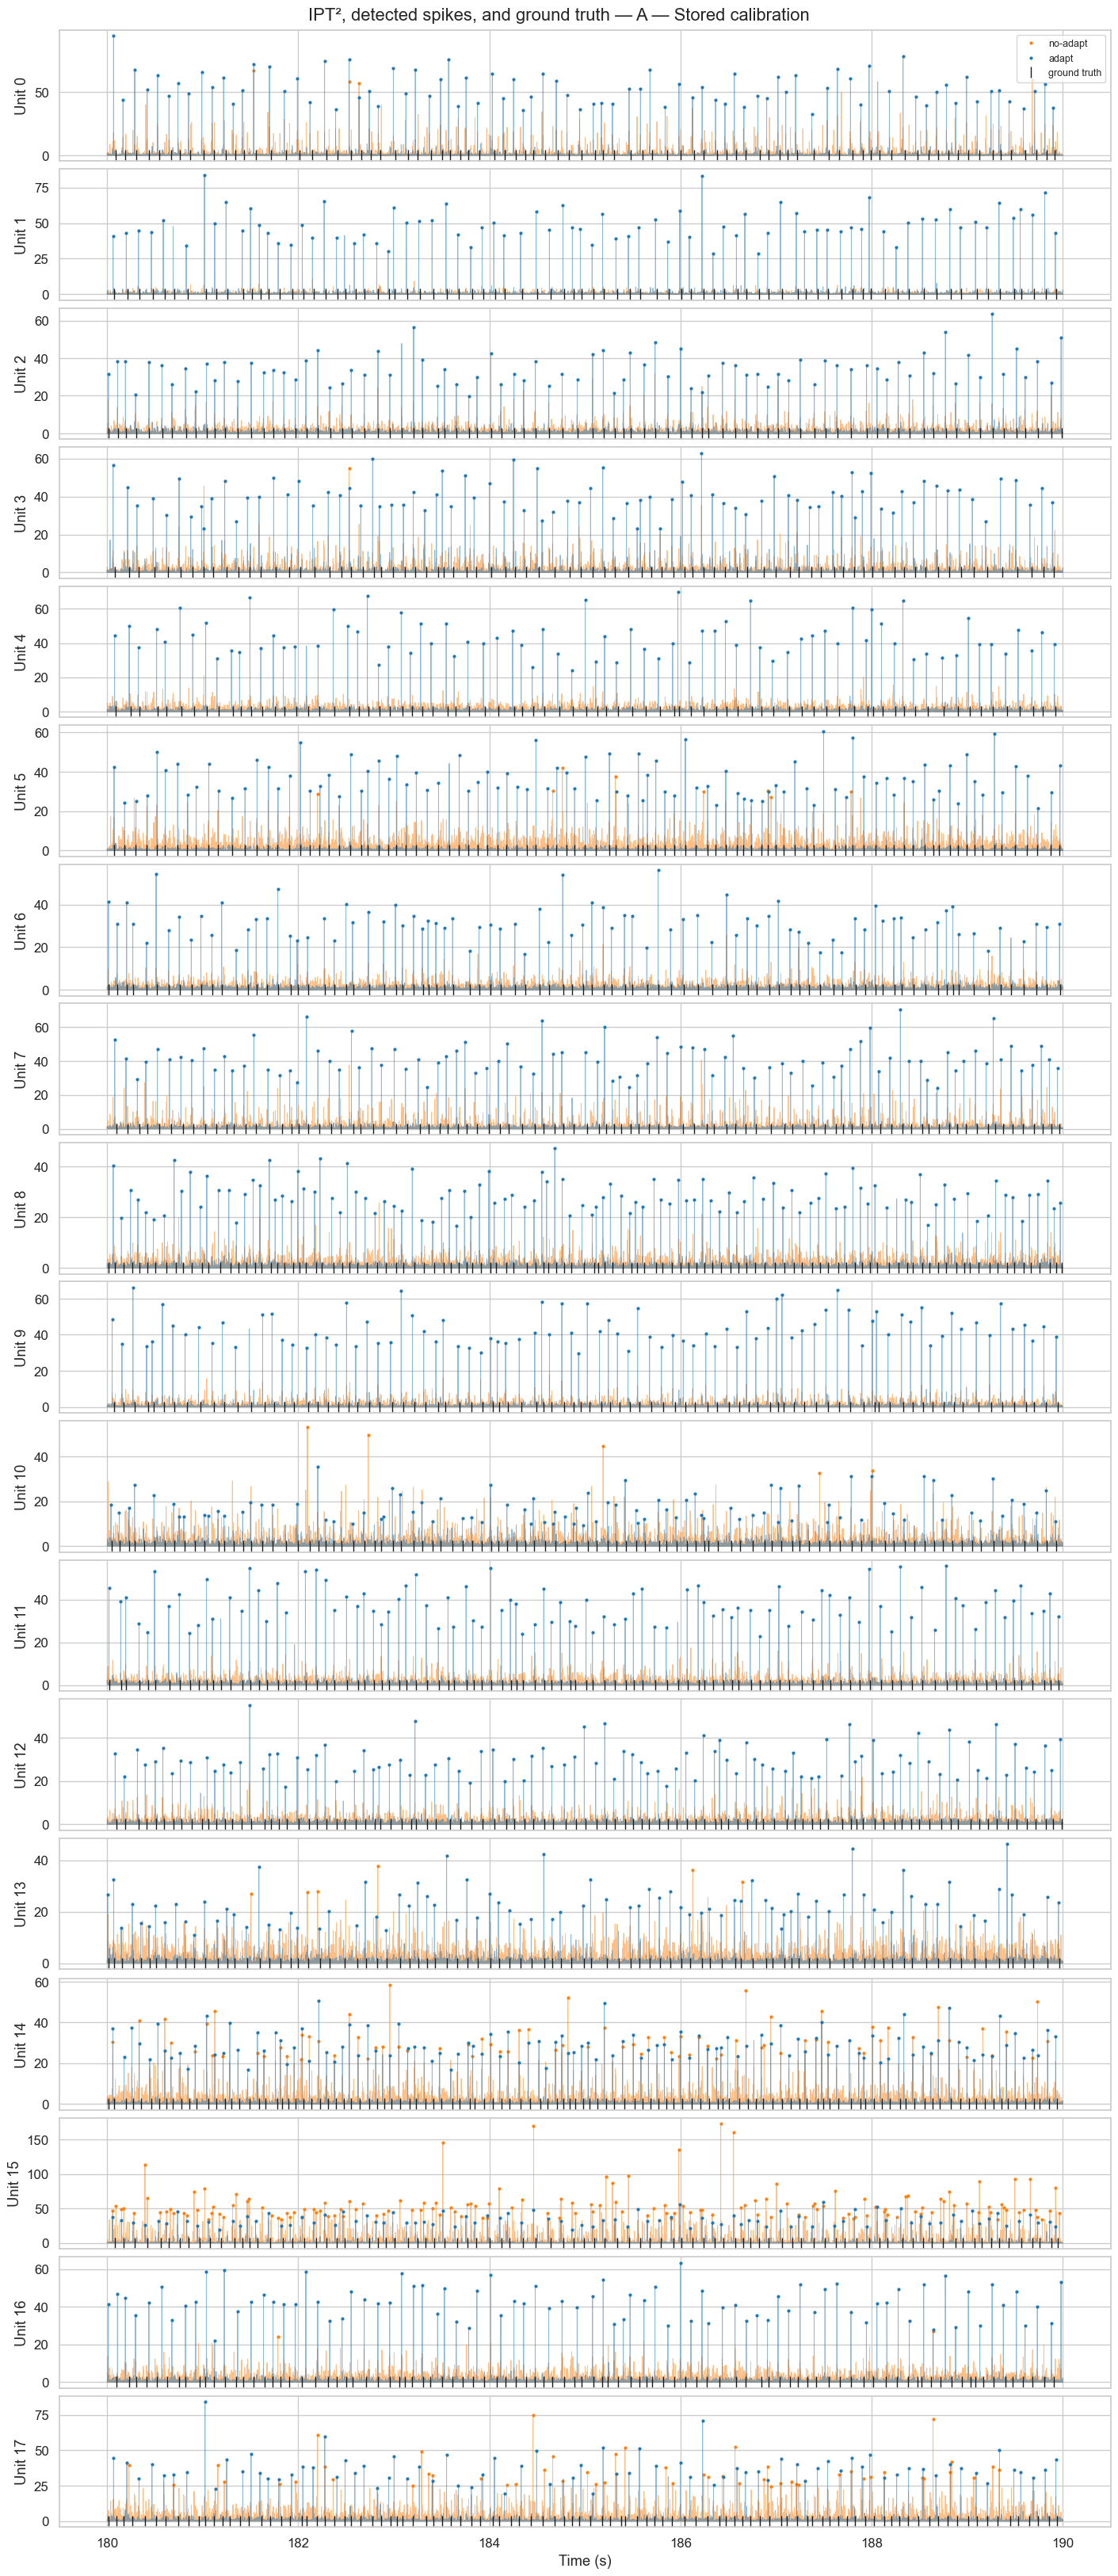

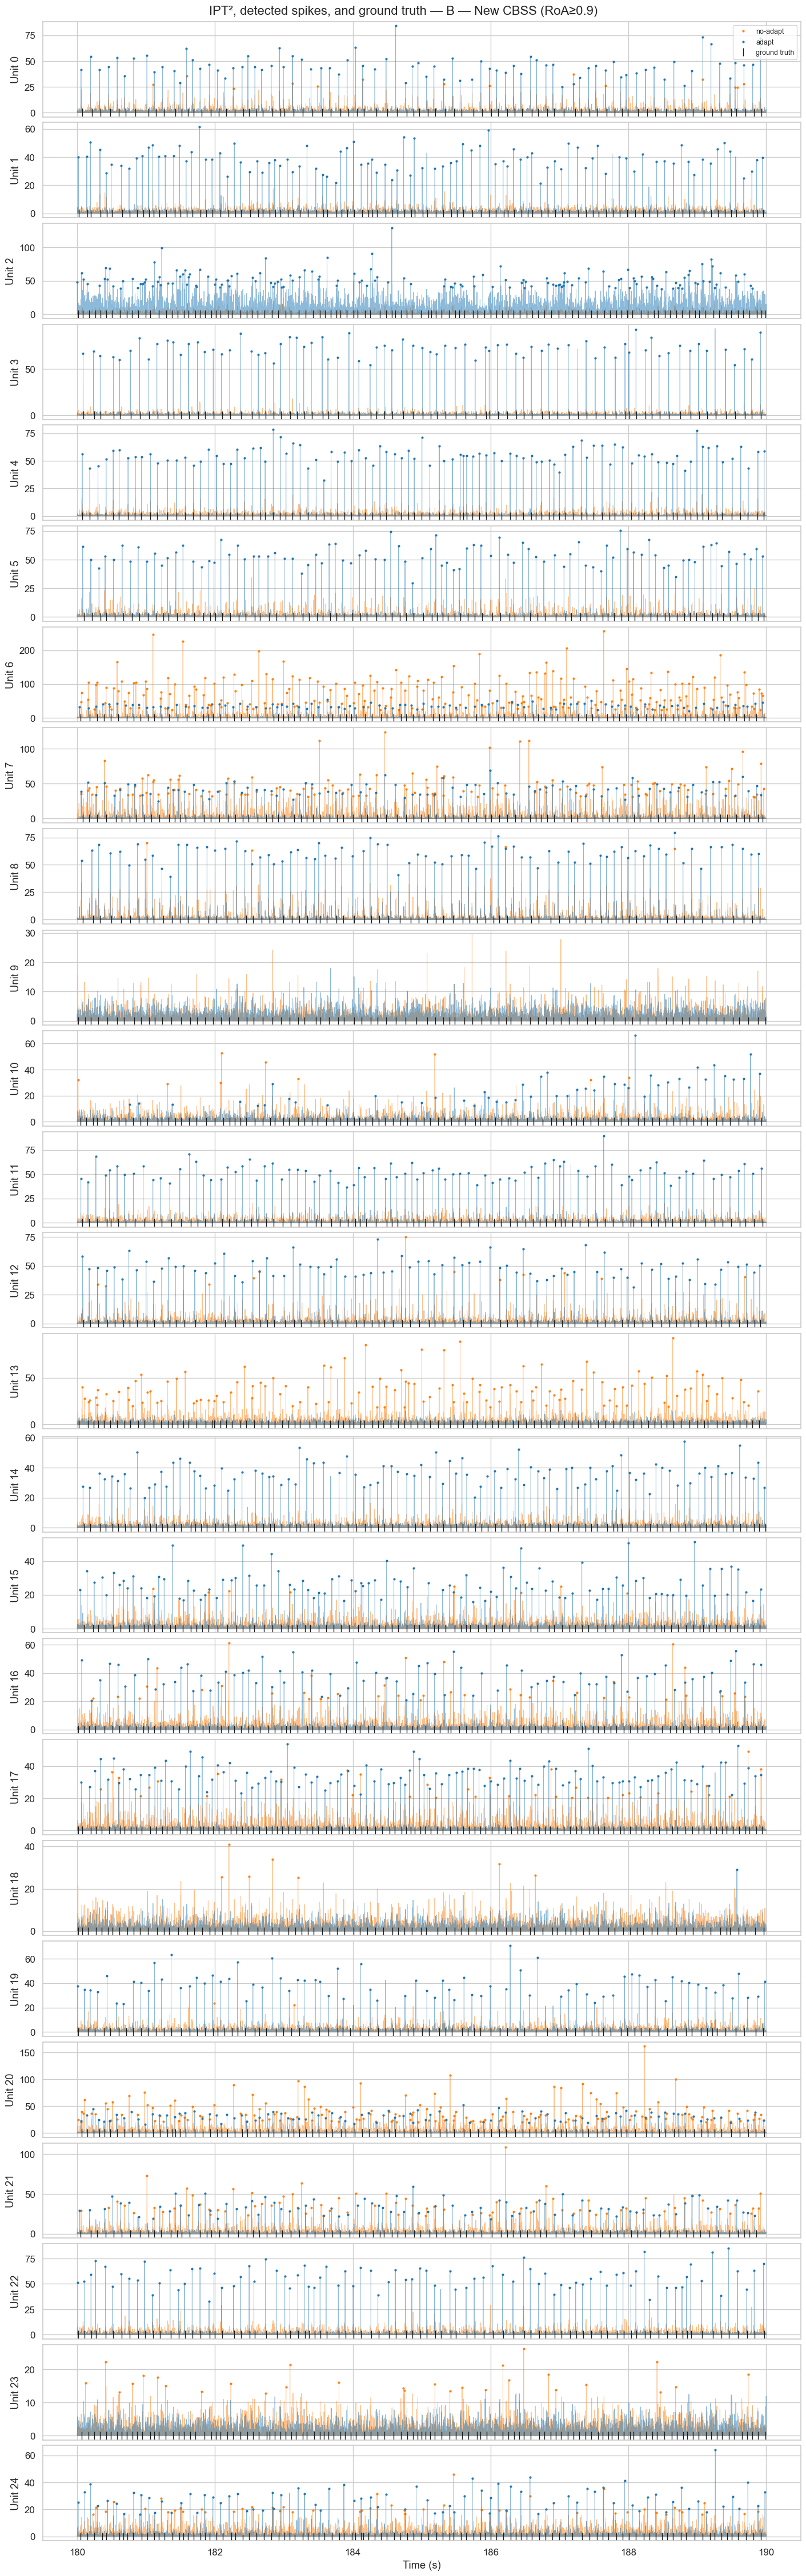

In [15]:
sim_spikes_a = data['spikes_gt'].numpy()[:, gt_matched_a]                 # [T, n_a], aligned to Path A unit order
sim_spikes_b = data['spikes_gt'].numpy()[:, selected.gt_matched_indices]  # [T, n_b], aligned to Path B unit order

t0_s, t1_s = (n_samples / fs) - 10, n_samples / fs
idxs = np.arange(int(t0_s * fs), int(t1_s * fs))

for path_lbl, out_no, out_ad, n_units, gt_spikes in [
    ('A — Stored calibration', out_a_no, out_a, n_a, sim_spikes_a),
    (f'B — New CBSS (RoA≥{ROA_TH})', out_b_no, out_b, n_b, sim_spikes_b),
]:
    fig, axes = plt.subplots(n_units, 1, figsize=(14, n_units * 1.8),
                             layout='constrained', sharex=True)
    if n_units == 1:
        axes = [axes]

    for u in range(n_units):
        ax = axes[u]
        for out, lbl, col in [
            (out_no, 'no-adapt', COLORS['no_adapt']),
            (out_ad, 'adapt',    COLORS['adapt']),
        ]:
            ipt2 = out['ipts'][idxs, u].numpy() ** 2
            ax.plot(data['timestamps'][idxs], ipt2, color=col, alpha=0.5, lw=0.7)
            sp_mask = out['spikes'][idxs, u].bool().numpy()
            ax.plot(data['timestamps'][idxs][sp_mask], ipt2[sp_mask], '.', color=col, markersize=4,
                    label=lbl if u == 0 else None)

        gt_mask = gt_spikes[idxs, u].astype(bool)
        ax.plot(data['timestamps'][idxs][gt_mask], np.zeros(gt_mask.sum()), '|', color='k',
                markersize=10, label='ground truth' if u == 0 else None)
        ax.set(ylabel=f'Unit {u}')

    axes[0].legend(loc='upper right', fontsize=9)
    axes[-1].set(xlabel='Time (s)')
    plt.suptitle(f'IPT², detected spikes, and ground truth — {path_lbl}')
    plt.show()

### 4.4 Rate of agreement vs. ground truth (full recording)

The real payoff of this dataset: since the true spike trains are known, adaptation quality can be scored directly rather than only compared between paths.

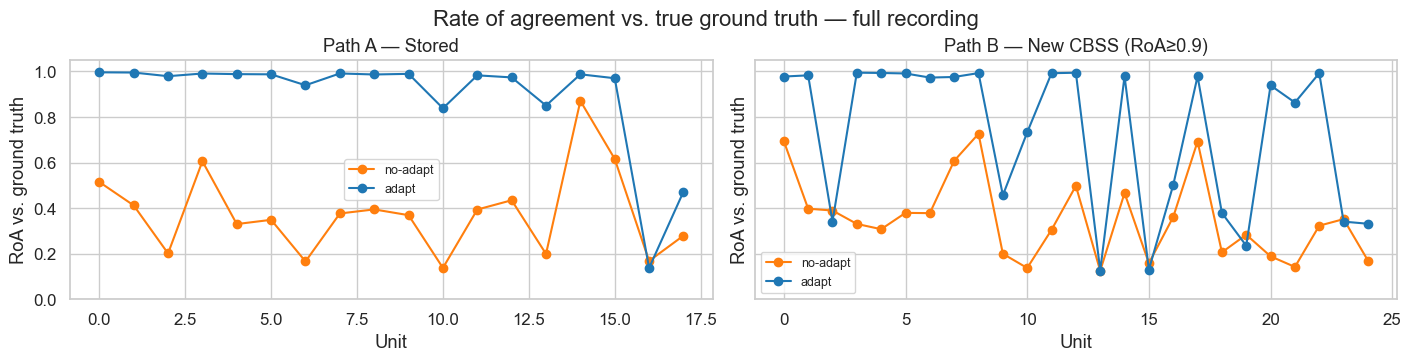

In [16]:
roa_a_no, _, _ = rate_of_agreement_paired(sim_spikes_a, out_a_no['spikes'].numpy(), fs=fs, tol_spike_ms=2)
roa_a,    _, _ = rate_of_agreement_paired(sim_spikes_a, out_a['spikes'].numpy(),    fs=fs, tol_spike_ms=2)
roa_b_no, _, _ = rate_of_agreement_paired(sim_spikes_b, out_b_no['spikes'].numpy(), fs=fs, tol_spike_ms=2)
roa_b,    _, _ = rate_of_agreement_paired(sim_spikes_b, out_b['spikes'].numpy(),    fs=fs, tol_spike_ms=2)

fig, axes = plt.subplots(1, 2, figsize=(14, 3.5), layout='constrained', sharey=True)
for ax, roa_no, roa_ad, n_units, title in [
    (axes[0], roa_a_no, roa_a, n_a, 'Path A — Stored'),
    (axes[1], roa_b_no, roa_b, n_b, f'Path B — New CBSS (RoA≥{ROA_TH})'),
]:
    ax.plot(roa_no, marker='o', label='no-adapt', color=COLORS['no_adapt'])
    ax.plot(roa_ad, marker='o', label='adapt',    color=COLORS['adapt'])
    ax.set(xlabel='Unit', ylabel='RoA vs. ground truth', title=title, ylim=(0, 1.05))
    ax.legend(fontsize=9)

plt.suptitle('Rate of agreement vs. true ground truth — full recording')
plt.show()

### 4.5 Summary statistics

In [17]:
def spikes_per_unit(out):
    return out['spikes'].sum(0).numpy().astype(float)

sp_a_no = spikes_per_unit(out_a_no)
sp_a    = spikes_per_unit(out_a)
sp_b_no = spikes_per_unit(out_b_no)
sp_b    = spikes_per_unit(out_b)

print('Total detected spikes (full recording)')
print(f'  A no-adapt:  {sp_a_no.sum():.0f}  (per unit: {sp_a_no.mean():.0f} ± {sp_a_no.std():.0f})')
print(f'  A adapt:     {sp_a.sum():.0f}  (per unit: {sp_a.mean():.0f} ± {sp_a.std():.0f})')
print(f'  B no-adapt:  {sp_b_no.sum():.0f}  (per unit: {sp_b_no.mean():.0f} ± {sp_b_no.std():.0f})')
print(f'  B adapt:     {sp_b.sum():.0f}  (per unit: {sp_b.mean():.0f} ± {sp_b.std():.0f})')

print('\nRate of agreement vs. ground truth (full recording, mean ± std / median)')
for lbl, roa in [('A no-adapt', roa_a_no), ('A adapt', roa_a),
                  ('B no-adapt', roa_b_no), ('B adapt', roa_b)]:
    print(f'  {lbl:<14}: {roa.mean()*100:5.2f} ± {roa.std()*100:4.2f} (med {np.median(roa)*100:5.2f}) %')

print('\nMean whitening loss')
print(f'  A no-adapt:  {out_a_no["wh_loss"].mean().item():.4f}')
print(f'  A adapt:     {out_a["wh_loss"].mean().item():.4f}')
print(f'  B no-adapt:  {out_b_no["wh_loss"].mean().item():.4f}')
print(f'  B adapt:     {out_b["wh_loss"].mean().item():.4f}')

print('\nMedian SV loss (across units and batches)')
for lbl, out in [('A no-adapt', out_a_no), ('A adapt', out_a),
                  ('B no-adapt', out_b_no), ('B adapt', out_b)]:
    print(f'  {lbl:<14}: {np.nanmedian(out["sv_loss"].numpy()):.4f}')

Total detected spikes (full recording)
  A no-adapt:  16775  (per unit: 932 ± 542)
  A adapt:     30717  (per unit: 1706 ± 190)
  B no-adapt:  27640  (per unit: 1106 ± 623)
  B adapt:     41026  (per unit: 1641 ± 286)

Rate of agreement vs. ground truth (full recording, mean ± std / median)
  A no-adapt    : 37.88 ± 18.23 (med 37.29) %
  A adapt       : 89.22 ± 21.97 (med 98.50) %
  B no-adapt    : 35.28 ± 17.58 (med 33.08) %
  B adapt       : 72.79 ± 32.23 (med 97.33) %

Mean whitening loss
  A no-adapt:  25000.9980
  A adapt:     1959.7628
  B no-adapt:  25217.8906
  B adapt:     3767.1326

Median SV loss (across units and batches)
  A no-adapt    : 1.8502
  A adapt       : 13.6280
  B no-adapt    : 1.5487
  B adapt       : 2.0654


## 5. Summary

| | Path A (stored) | Path B (new CBSS) |
|--|--|--|
| **Calibration** | Loaded from `decomp_sim.mat` | `calibrate_from_indices()` |
| **Unit selection** | All stored units | `select_units_supervised(roa_th=0.9)` vs. true ground truth |
| **GT matching** | `rate_of_agreement()` post hoc (all units kept regardless of match quality) | `gt_matched_indices` from supervised selection |
| **AdaptDecomp** | `AdaptDecomp(...)` | `AdaptDecomp.from_calibration(...)` |
| **# units** | `data['sep_vectors'].shape[0]` | `selected.sources.shape[1]` |
| **Evaluation** | RoA vs. true simulated spikes (§4.4) | RoA vs. true simulated spikes (§4.4) |